(768.0*(-324*pi**4 + 256 + 1872*pi**2 + 729*pi**6)*sqrt(-4*pi**4 + 256 + pi**6 + 208*pi**2)*(-pi**4 + 4 + 13*pi**2 + pi**6)*sin(pi*t/2 - atan(pi*(20 - pi**2)/(2*(8 - 3*pi**2)))) + 192.0*pi**2*(-324*pi**4 + 256 + 1872*pi**2 + 729*pi**6)*sqrt(-4*pi**4 + 256 + pi**6 + 208*pi**2)*(-pi**4 + 4 + 13*pi**2 + pi**6)*sin(pi*t/2 - atan(pi*(20 - pi**2)/(2*(8 - 3*pi**2)))) - 12.0*pi**2*(-324*pi**4 + 256 + 1872*pi**2 + 729*pi**6)*(-4*pi**4 + 256 + pi**6 + 208*pi**2)*sqrt(-pi**4 + 4 + 13*pi**2 + pi**6)*sin(pi*t - atan(pi*(5 - pi**2)/(2 - 3*pi**2))) - 12.0*(-324*pi**4 + 256 + 1872*pi**2 + 729*pi**6)*(-4*pi**4 + 256 + pi**6 + 208*pi**2)*sqrt(-pi**4 + 4 + 13*pi**2 + pi**6)*sin(pi*t - atan(pi*(5 - pi**2)/(2 - 3*pi**2))) + 28.4444444444444*sqrt(-324*pi**4 + 256 + 1872*pi**2 + 729*pi**6)*(-4*pi**4 + 256 + pi**6 + 208*pi**2)*(-pi**4 + 4 + 13*pi**2 + pi**6)*sin(3*pi*t/2 - atan(3*pi*(-20 + 9*pi**2)/(2*(-8 + 27*pi**2)))) + 64.0*pi**2*sqrt(-324*pi**4 + 256 + 1872*pi**2 + 729*pi**6)*(-4*pi**4 + 256 + pi**6 + 208

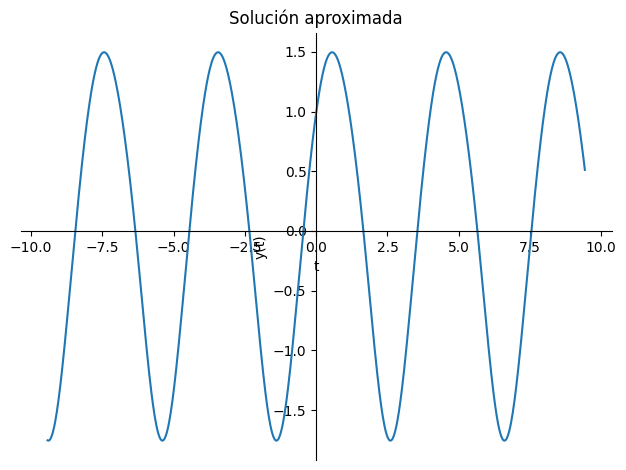

In [37]:
import sympy as sp

def resolver_ed_periodica(f, L, N, coeficientes):
    """
    Resuelve EDOs lineales con entradas periódicas usando series de Fourier.
    
    Parámetros:
        f (sympy.Expr): Función periódica de entrada
        L (float): Semi-periodo (T = 2L)
        N (int): Número de términos de la serie
        coeficientes (list): Coeficientes de la EDO [a_m, ..., a_1, a_0]
        
    Retorna:
        sympy.Expr: Solución aproximada en estado estacionario
    """
    t, s = sp.symbols('t s')
    omega = sp.pi/L  # Frecuencia fundamental
    
    # Construir función de transferencia
    denominador = sum(coef*s**k for k, coef in enumerate(reversed(coeficientes)))
    T = 1/denominador
    
    # Calcular coeficientes de Fourier
    a0 = (1/L) * sp.integrate(f, (t, -L, L))
    y = (a0/2) * T.subs(s, 0)  # Término DC
    
    for n in range(1, N+1):
        # Coeficientes de Fourier
        an = (1/L) * sp.integrate(f*sp.cos(n*omega*t), (t, -L, L))
        bn = (1/L) * sp.integrate(f*sp.sin(n*omega*t), (t, -L, L))
        
        # Evaluar función de transferencia en s = i*n*omega
        T_val = T.subs(s, sp.I*n*omega)
        magnitud = sp.Abs(T_val)
        fase = sp.arg(T_val)
        
        # Construir término de la solución
        termino = magnitud*(an*sp.cos(n*omega*t + fase) + bn*sp.sin(n*omega*t + fase))
        y += termino
    
    return y.expand().simplify()

# Ejemplo de uso (caso del profesor):
if __name__ == "__main__":
    t = sp.symbols('t')
    
    # Configuración del problema
    L = 2  # Semi-periodo (T = 2π)
    f = t**3-10*t
    N = 3     # Función periódica f(t) = t en (-π, π)
    coeficientes = [1, 3, 5, 2]  # y'' + 2y' + 2y
    
    # Resolver y mostrar
    sol1 = resolver_ed_periodica(f, L, N, coeficientes)

    print(sol1)
    
    # Graficar (opcional)
    grafica = sp.plot(sol1,(t, -3*sp.pi, 3*sp.pi), 
                    title='Solución aproximada', 
                    xlabel='t', ylabel='y(t)', 
                    show=False)
    grafica.show()

In [29]:
X, Y, Z, z = sp.symbols("X Y Z z")
sp.solve([z*X-Y-1,z*Y+X-1],[X, Y])

{X: (z + 1)/(z**2 + 1), Y: (z - 1)/(z**2 + 1)}

In [30]:
sp.solve([z*X+1-Y-Z,z*Y+1+X-Z, z*Z+1+X+Y],[X, Y, Z])

{X: (-z**2 - 2*z - 1)/(z**3 + 3*z),
 Y: (1 - z**2)/(z**3 + 3*z),
 Z: (-z**2 + 2*z - 1)/(z**3 + 3*z)}

In [31]:
sp.inverse_laplace_transform((-z**2 + 2*z - 1)/(z**3 + 3*z),z,t)

(2*sqrt(3)*sin(sqrt(3)*t)/3 - 2*cos(sqrt(3)*t)/3)*Heaviside(t) - Heaviside(t)/3

In [32]:
sp.inverse_laplace_transform((-z**2 - 2*z - 1)/(z**3 + 3*z),z,t)

(-2*sqrt(3)*sin(sqrt(3)*t)/3 - 2*cos(sqrt(3)*t)/3)*Heaviside(t) - Heaviside(t)/3

In [33]:
sp.inverse_laplace_transform((1 - z**2)/(z**3 + 3*z),z,t)

-4*cos(sqrt(3)*t)*Heaviside(t)/3 + Heaviside(t)/3